# DNGO-Based Bayesian Optimization

## Overview
- **Surrogate Model**: DNGO (Deep Networks for Global Optimization)
- **Architecture**: DNN (feature extraction) + Bayesian Linear Regression (uncertainty)
- **Strategy**: Transfer Learning (Pretrain on low-fidelity → Finetune on high-fidelity)
- **Acquisition Function**: Expected Improvement (EI)
- **Multi-Fidelity**: 10:1 ratio (10× ShortCut → 1× Rigorous)

## Sampling Plan
- **Initial**: 90 low-fidelity (ShortCut) + 10 high-fidelity (Rigorous) = 100 samples
- **Main Loop**: 300 iterations with 10:1 fidelity scheduling
- **Total**: 400 evaluations

In [11]:
cd ~/MultiFidelity-ProcessOpt/Process/1.\ Code

/Users/k23070952/MultiFidelity-ProcessOpt/Process/1. Code


In [12]:
# Core imports
from ShortCutDesign import ShortCutDesign
from RigorousDesign import RigorousDesign
import pandas as pd
import numpy as np
import os
import time
from datetime import datetime

# PyTorch for DNN
import torch
import torch.nn as nn
import torch.optim as optim

# Statistical functions
from scipy.stats import norm, qmc
from scipy.optimize import differential_evolution

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Detect available device (MPS > CUDA > CPU)
if torch.backends.mps.is_available():
    device = 'mps'
    print(f"✓ Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = 'cuda'
    print(f"✓ Using NVIDIA GPU (CUDA)")
else:
    device = 'cpu'
    print(f"⚠️  Using CPU (no GPU available)")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

✓ Using Apple Silicon GPU (MPS)
PyTorch version: 2.4.1
Device: mps


## DNGO Components

### 1. TransferLearningDNN
- Feature extractor using neural network
- Supports transfer learning (pretrain → finetune)

### 2. BayesianLinearRegression
- Operates on DNN features
- Provides uncertainty quantification

In [13]:
class TransferLearningDNN:
    """
    Deep Neural Network for feature extraction with transfer learning.
    
    Architecture:
        Input (8D) → Linear(64) → ReLU → Linear(64) → ReLU [feature_net]
                                                         ↓
                                                    Linear(1) [out_layer]
    """
    def __init__(self, input_dim=8, hidden_dim=64, device='cpu'):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.device = torch.device(device)
        
        # Feature extraction network
        self.feature_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        ).to(self.device).float()
        
        # Output layer (for end-to-end training)
        self.out_layer = nn.Linear(hidden_dim, 1, bias=False).to(self.device).float()
        
        # Full model
        self.model = nn.Sequential(self.feature_net, self.out_layer)
        
    def pretrain(self, X_low, y_low, epochs=200, lr=1e-3, verbose=True):
        """
        Pretrain on low-fidelity data (ShortCut design)
        """
        if len(X_low) == 0:
            if verbose:
                print("⚠️  No low-fidelity data available for pretraining")
            return
        
        X_tensor = torch.tensor(X_low, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y_low, dtype=torch.float32).view(-1, 1).to(self.device)
        
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        
        self.model.train()
        losses = []
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            pred = self.model(X_tensor)
            loss = loss_fn(pred, y_tensor)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            
            if verbose and (epoch + 1) % 50 == 0:
                print(f"  Pretrain Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        
        if verbose:
            print(f"✓ Pretrain completed. Final loss: {losses[-1]:.6f}")
    
    def finetune(self, X_high, y_high, epochs=100, lr=1e-4, verbose=True):
        """
        Finetune on high-fidelity data (Rigorous design)
        """
        if len(X_high) == 0:
            if verbose:
                print("⚠️  No high-fidelity data available for finetuning")
            return
        
        X_tensor = torch.tensor(X_high, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y_high, dtype=torch.float32).view(-1, 1).to(self.device)
        
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        
        self.model.train()
        losses = []
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            pred = self.model(X_tensor)
            loss = loss_fn(pred, y_tensor)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            
            if verbose and (epoch + 1) % 25 == 0:
                print(f"  Finetune Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        
        if verbose:
            print(f"✓ Finetune completed. Final loss: {losses[-1]:.6f}")
    
    def extract_features(self, X):
        """
        Extract features φ(x) from feature_net
        """
        self.feature_net.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            features = self.feature_net(X_tensor)
            return features.cpu().numpy()
    
    def predict(self, X):
        """
        Full model prediction (for validation)
        """
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            pred = self.model(X_tensor)
            return pred.cpu().numpy().flatten()

print("✓ TransferLearningDNN class defined")

✓ TransferLearningDNN class defined


In [14]:
class BayesianLinearRegression:
    """
    Bayesian Linear Regression on DNN features.
    
    Math:
        Prior: p(w) = N(0, α^(-1)I)
        Likelihood: p(y|X,w) = N(Xw, β^(-1)I)
        Posterior: p(w|X,y) = N(m_N, S_N)
        
        where:
            S_N^(-1) = α·I + β·Φ^T·Φ
            m_N = β·S_N·Φ^T·y
    """
    def __init__(self, alpha=1.0, beta=25.0):
        self.alpha = alpha  # Weight precision
        self.beta = beta    # Noise precision
        self.mean = None    # Posterior mean m_N
        self.cov = None     # Posterior covariance S_N
        self.fitted = False
    
    def fit(self, X, y):
        """
        Fit BLR on features X (from DNN) and targets y
        """
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32).flatten()
        
        # Add bias term
        N = len(X)
        X_with_bias = np.column_stack([np.ones(N), X])
        
        # Prior covariance inverse
        D = X_with_bias.shape[1]
        S0_inv = self.alpha * np.eye(D)
        
        # Posterior covariance
        S_N_inv = S0_inv + self.beta * (X_with_bias.T @ X_with_bias)
        self.cov = np.linalg.inv(S_N_inv)
        
        # Posterior mean
        self.mean = self.beta * (self.cov @ X_with_bias.T @ y)
        
        self.fitted = True
    
    def predict(self, x):
        """
        Predict with uncertainty for a single feature vector
        
        Returns:
            mu: Predictive mean
            var: Predictive variance
        """
        if not self.fitted:
            raise ValueError("Model not fitted yet")
        
        x = np.asarray(x, dtype=np.float32).flatten()
        x_with_bias = np.concatenate([[1.0], x])
        
        # Predictive distribution
        mu = x_with_bias @ self.mean
        var = (1.0 / self.beta) + (x_with_bias @ self.cov @ x_with_bias)
        
        return mu, var
    
    def predict_batch(self, X):
        """
        Vectorized prediction for multiple feature vectors
        
        Returns:
            means: Array of predictive means
            vars: Array of predictive variances
        """
        if not self.fitted:
            raise ValueError("Model not fitted yet")
        
        X = np.asarray(X, dtype=np.float32)
        N = len(X)
        X_with_bias = np.column_stack([np.ones(N), X])
        
        # Predictive means
        means = X_with_bias @ self.mean
        
        # Predictive variances
        vars = np.array([
            (1.0 / self.beta) + (x @ self.cov @ x)
            for x in X_with_bias
        ])
        
        return means, vars

print("✓ BayesianLinearRegression class defined")

✓ BayesianLinearRegression class defined


## Helper Functions

### Expected Improvement
Acquisition function for selecting next point to evaluate.

### fit_blr
Train separate BLR models for low and high fidelity.

### recommend_next
Find point with maximum Expected Improvement.

In [15]:
def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Expected Improvement acquisition function
    
    Args:
        mu: Predicted means (array)
        sigma: Predicted standard deviations (array)
        y_best: Best observed value so far
        xi: Exploration parameter (default: 0.01)
    
    Returns:
        ei: Expected improvement values
    """
    sigma = np.maximum(sigma, 1e-8)  # Numerical stability
    
    z = (y_best - mu - xi) / sigma
    ei = (y_best - mu - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    
    return ei


def fit_blr(model, X_low, X_high, y_low, y_high, alpha=1.0, beta=25.0, verbose=False):
    """
    Fit BLR models for both fidelities
    
    Returns:
        blr_low: BLR trained on low-fidelity features only
        blr_high: BLR trained on all features (transfer learning)
    """
    # LOFI model (low-fidelity only)
    blr_low = None
    if len(X_low) > 0:
        features_low = model.extract_features(X_low)
        blr_low = BayesianLinearRegression(alpha, beta)
        blr_low.fit(features_low, y_low)
        if verbose:
            print(f"  BLR-LOW fitted with {len(X_low)} samples")
    
    # HIFI model (transfer learning: combine low + high)
    blr_high = None
    if len(X_high) > 0:
        # Combine data from both fidelities
        X_all = np.vstack([X_low, X_high]) if len(X_low) > 0 else X_high
        y_all = np.concatenate([y_low, y_high]) if len(y_low) > 0 else y_high
        
        features_all = model.extract_features(X_all)
        blr_high = BayesianLinearRegression(alpha, beta)
        blr_high.fit(features_all, y_all)
        if verbose:
            print(f"  BLR-HIGH fitted with {len(X_all)} samples (transfer learning)")
    else:
        # No high-fidelity data yet, use low-fidelity model
        blr_high = blr_low
    
    return blr_low, blr_high


def recommend_next(model, blr_low, blr_high, bounds, 
                   X_low, X_high, y_low, y_high, fidelity,
                   n_candidates=1000, verbose=False):
    """
    Recommend next point to evaluate based on Expected Improvement
    
    Args:
        model: Trained DNN
        blr_low, blr_high: Fitted BLR models
        bounds: Variable bounds [(min, max), ...]
        X_low, X_high: Observed points at each fidelity
        y_low, y_high: Observed values at each fidelity
        fidelity: Current fidelity ("low" or "high")
        n_candidates: Number of random candidates to generate
    
    Returns:
        next_x: Recommended point (8D array)
        ei_max: Maximum EI value
    """
    # Generate random candidate points using Latin Hypercube Sampling
    sampler = qmc.LatinHypercube(d=len(bounds), seed=np.random.randint(0, 10000))
    unit_samples = sampler.random(n=n_candidates)
    
    # Scale to bounds
    X_candidates = np.zeros_like(unit_samples)
    for i, (low, high) in enumerate(bounds):
        X_candidates[:, i] = unit_samples[:, i] * (high - low) + low
    
    # Enforce integer constraint on first variable (number of stages)
    X_candidates[:, 0] = np.round(X_candidates[:, 0]).astype(int)
    
    # Extract features
    features_candidates = model.extract_features(X_candidates)
    
    # Select appropriate BLR and best value
    if fidelity == "high":
        blr = blr_high
        y_best = np.min(y_high) if len(y_high) > 0 else np.inf
    else:  # "low"
        blr = blr_low if blr_low is not None else blr_high
        y_best = np.min(y_low) if len(y_low) > 0 else np.inf
    
    # Predict for all candidates
    means, vars = blr.predict_batch(features_candidates)
    stds = np.sqrt(vars)
    
    # Compute Expected Improvement
    ei = expected_improvement(means, stds, y_best)
    
    # Filter out already measured points at current fidelity
    measured = set([tuple(x) for x in (X_high if fidelity == "high" else X_low)])
    valid_indices = [i for i, x in enumerate(X_candidates) if tuple(x) not in measured]
    
    # Select point with maximum EI
    if valid_indices:
        valid_ei = ei[valid_indices]
        best_valid_idx = np.argmax(valid_ei)
        best_idx = valid_indices[best_valid_idx]
    else:
        best_idx = np.argmax(ei)
    
    next_x = X_candidates[best_idx]
    ei_max = ei[best_idx]
    
    if verbose:
        print(f"  Selected point: {next_x}")
        print(f"  EI: {ei_max:.6f}, Predicted mean: {means[best_idx]:.4f}, Predicted std: {stds[best_idx]:.4f}")
    
    return next_x, ei_max

print("✓ Helper functions defined")

✓ Helper functions defined


## Simulation Functions

Interface to ShortCutDesign and RigorousDesign classes.

In [16]:
def calculate_shortcut(_init_params):
    """
    Calculate low-fidelity (ShortCut) design
    """
    shortcut_model = ShortCutDesign(verbose=False)
    shortcut_results = shortcut_model.shortcut_results(_init_params)
    return shortcut_results


def calculate_rigorous(_init_params):
    """
    Calculate high-fidelity (Rigorous) design
    
    Returns:
        (shortcut_results, rigorous_results)
        where rigorous_results = [CAPEX, OPEX, AceticAcid_wt, time, MSP]
    """
    shortcut_results = calculate_shortcut(_init_params)
    
    # Check if shortcut failed
    if shortcut_results['CAPEX'] == 0:
        return (shortcut_results, [0, 0, 0, 0, 10000])
    
    if shortcut_results['CAPEX'] is None or np.isnan(shortcut_results['CAPEX']):
        return (shortcut_results, [0, 0, 0, 0, 10000])
    
    # Calculate rigorous design
    try:
        rigorous_model = RigorousDesign(verbose=False)
        rigorous_results = rigorous_model.func(_init_params, shortcut_results)
        return (shortcut_results, rigorous_results)
    except Exception as e:
        print(f"Error in rigorous calculation: {e}")
        return (shortcut_results, [0, 0, 0, 0, 10000])

print("✓ Simulation functions defined")

✓ Simulation functions defined


## Configuration

In [17]:
# File paths
timestamp = datetime.now().strftime("%y%m%d_%H%M%S")
results_dir = '../3. Data'
os.makedirs(results_dir, exist_ok=True)
results_file = f'{results_dir}/dngo_bo_results_{timestamp}.csv'

# Optimization parameters
NUM_INIT_LOW = 90      # Initial low-fidelity samples
NUM_INIT_HIGH = 10     # Initial high-fidelity samples
NUM_ITERATIONS = 100   # Additional iterations
FIDELITY_RATIO = 10    # 10 low-fidelity : 1 high-fidelity

# DNGO model parameters
INPUT_DIM = 8
HIDDEN_DIM = 64
PRETRAIN_EPOCHS = 200
FINETUNE_EPOCHS = 100
PRETRAIN_LR = 1e-3
FINETUNE_LR = 1e-4

# BLR parameters
ALPHA = 1.0
BETA = 25.0

# Variable bounds
bounds = [
    (10, 50),      # n1: Extractor stages (integer)
    (0, 0.9999),   # Lr1: Light key recovery 1
    (0, 0.9999),   # Hr1: Heavy key recovery 1
    (0, 0.9999),   # Lr2: Light key recovery 2
    (0, 0.9999),   # Hr2: Heavy key recovery 2
    (273, 350),    # T_hex: Heat exchanger temperature (K)
    (0, 0.9999),   # Lr3: Light key recovery 3
    (0, 0.9999),   # Hr3: Heavy key recovery 3
]

# Device (already set in imports cell, but show configuration)
print(f"Configuration:")
print(f"  Initial samples: {NUM_INIT_LOW} low + {NUM_INIT_HIGH} high = {NUM_INIT_LOW + NUM_INIT_HIGH}")
print(f"  Additional iterations: {NUM_ITERATIONS}")
print(f"  Fidelity ratio: {FIDELITY_RATIO}:1 (low:high)")
print(f"  Total evaluations: ~{NUM_INIT_LOW + NUM_INIT_HIGH + NUM_ITERATIONS}")
print(f"  Device: {device}")
print(f"  Results file: {results_file}")

Configuration:
  Initial samples: 90 low + 10 high = 100
  Additional iterations: 100
  Fidelity ratio: 10:1 (low:high)
  Total evaluations: ~200
  Device: mps
  Results file: ../3. Data/dngo_bo_results_251024_154640.csv


## Initial Sampling

Generate 100 initial samples:
- 90 low-fidelity (ShortCut)
- 10 high-fidelity (Rigorous)

In [18]:
print("=" * 80)
print("INITIAL SAMPLING PHASE")
print("=" * 80)

# Generate Latin Hypercube samples
sampler = qmc.LatinHypercube(d=INPUT_DIM, seed=42)
unit_samples = sampler.random(n=NUM_INIT_LOW + NUM_INIT_HIGH)

# Scale to bounds
init_samples = np.zeros_like(unit_samples)
for i, (low, high) in enumerate(bounds):
    init_samples[:, i] = unit_samples[:, i] * (high - low) + low

# Enforce integer constraint on first variable
init_samples[:, 0] = np.round(init_samples[:, 0]).astype(int)

# Separate into low and high fidelity
init_low_samples = init_samples[:NUM_INIT_LOW]
init_high_samples = init_samples[NUM_INIT_LOW:]

print(f"\nEvaluating {NUM_INIT_LOW} low-fidelity samples...")
X_low, y_low = [], []
init_records = []

for i, x in enumerate(init_low_samples):
    try:
        shortcut_results = calculate_shortcut(x)
        msp = shortcut_results.get('MSP', 10000)
        
        X_low.append(x)
        y_low.append(msp)
        
        # Save to CSV
        record = list(x) + [
            shortcut_results.get('CAPEX', 0),
            shortcut_results.get('OPEX', 0),
            shortcut_results.get('AceticAcidWt', 0),
            shortcut_results.get('SplitRatio', 0),
            shortcut_results.get('boilup_1', 0),
            shortcut_results.get('N_stages_1', 0),
            shortcut_results.get('feed_stage_1', 0),
            shortcut_results.get('boilup_2', 0),
            shortcut_results.get('N_stages_2', 0),
            shortcut_results.get('feed_stage_2', 0),
            shortcut_results.get('boilup_3', 0),
            shortcut_results.get('N_stages_3', 0),
            shortcut_results.get('feed_stage_3', 0),
            shortcut_results.get('shortcut_time', 0),
            None, None, None, None,  # Rigorous results (not available for low-fidelity)
            msp,
            'low',  # Fidelity
            'initial',  # Phase
            None  # Error
        ]
        init_records.append(record)
        
        if (i + 1) % 10 == 0:
            print(f"  Completed {i+1}/{NUM_INIT_LOW} (MSP: {msp:.4f})")
    
    except Exception as e:
        print(f"  Error at sample {i+1}: {e}")
        record = list(x) + [None] * 14 + [10000, 'low', 'initial', str(e)]
        init_records.append(record)

X_low = np.array(X_low)
y_low = np.array(y_low)

print(f"\nEvaluating {NUM_INIT_HIGH} high-fidelity samples...")
X_high, y_high = [], []

for i, x in enumerate(init_high_samples):
    try:
        shortcut_results, rigorous_results = calculate_rigorous(x)
        msp = rigorous_results[-1]  # Last element is MSP
        
        X_high.append(x)
        y_high.append(msp)
        
        # Save to CSV
        record = list(x) + [
            shortcut_results.get('CAPEX', 0),
            shortcut_results.get('OPEX', 0),
            shortcut_results.get('AceticAcidWt', 0),
            shortcut_results.get('SplitRatio', 0),
            shortcut_results.get('boilup_1', 0),
            shortcut_results.get('N_stages_1', 0),
            shortcut_results.get('feed_stage_1', 0),
            shortcut_results.get('boilup_2', 0),
            shortcut_results.get('N_stages_2', 0),
            shortcut_results.get('feed_stage_2', 0),
            shortcut_results.get('boilup_3', 0),
            shortcut_results.get('N_stages_3', 0),
            shortcut_results.get('feed_stage_3', 0),
            shortcut_results.get('shortcut_time', 0),
            rigorous_results[0],  # CAPEX
            rigorous_results[1],  # OPEX
            rigorous_results[2],  # AceticAcid_wt
            rigorous_results[3],  # time
            msp,
            'high',  # Fidelity
            'initial',  # Phase
            None  # Error
        ]
        init_records.append(record)
        
        print(f"  Completed {i+1}/{NUM_INIT_HIGH} (MSP: {msp:.4f})")
    
    except Exception as e:
        print(f"  Error at sample {i+1}: {e}")
        record = list(x) + [None] * 17 + [10000, 'high', 'initial', str(e)]
        init_records.append(record)

X_high = np.array(X_high)
y_high = np.array(y_high)

# Save initial results
columns = ['n1', 'Lr1', 'Hr1', 'Lr2', 'Hr2', 'T_hex', 'Lr3', 'Hr3',
           'sc_CAPEX', 'sc_OPEX', 'sc_AceticAcidWt', 'sc_SplitRatio',
           'sc_boilup_1', 'sc_N_stages_1', 'sc_feed_stage_1',
           'sc_boilup_2', 'sc_N_stages_2', 'sc_feed_stage_2',
           'sc_boilup_3', 'sc_N_stages_3', 'sc_feed_stage_3', 'sc_time',
           'rg_CAPEX', 'rg_OPEX', 'rg_AceticAcidWt', 'rg_time',
           'MSP', 'fidelity', 'phase', 'error']

df_init = pd.DataFrame(init_records, columns=columns)
df_init.to_csv(results_file, index=False)

print(f"\n{'='*80}")
print("INITIAL SAMPLING COMPLETED")
print(f"{'='*80}")
print(f"Low-fidelity samples: {len(X_low)}")
print(f"High-fidelity samples: {len(X_high)}")
print(f"Best low-fidelity MSP: {np.min(y_low):.4f}")
print(f"Best high-fidelity MSP: {np.min(y_high):.4f}")
print(f"Results saved to: {results_file}")

INITIAL SAMPLING PHASE

Evaluating 90 low-fidelity samples...
 ##### An instance of the 'BlackBox' class  has been initialised!
[4.700e+01 4.556e-01 1.814e-01 2.930e-01 4.290e-01 2.753e+02 3.724e-01
 4.214e-02]
Error occurred: <ShortcutColumn: acetic_acid_purification> tuple.index(x): x not in tuple
 ##### An instance of the 'BlackBox' class  has been initialised!
[2.200e+01 9.549e-02 9.262e-01 4.607e-01 9.535e-01 3.132e+02 8.455e-01
 3.877e-01]
 ##### An instance of the 'BlackBox' class  has been initialised!
[2.700e+01 5.936e-02 8.216e-01 4.336e-01 4.424e-01 2.820e+02 1.029e-02
 2.107e-02]
Error occurred: <ShortcutColumn: acetic_acid_purification> tuple.index(x): x not in tuple
 ##### An instance of the 'BlackBox' class  has been initialised!
[ 20.      0.748   0.935   0.649   0.718 279.404   0.413   0.37 ]
 ##### An instance of the 'BlackBox' class  has been initialised!
[3.400e+01 5.362e-01 3.453e-01 4.781e-01 7.086e-01 2.773e+02 1.577e-01
 8.432e-01]
 ##### An instance of the 'Bla

## Main DNGO Bayesian Optimization Loop

### Workflow per iteration:
1. Train DNN (pretrain → finetune)
2. Extract features for all candidates
3. Fit BLR models (low and high fidelity)
4. Compute Expected Improvement
5. Select point with maximum EI
6. Determine fidelity (10:1 schedule)
7. Evaluate selected point
8. Update datasets and records

In [19]:
print("\n" + "=" * 80)
print("DNGO BAYESIAN OPTIMIZATION LOOP")
print("=" * 80)

# Track best values
best_low = np.min(y_low)
best_high = np.min(y_high) if len(y_high) > 0 else np.inf
best_overall = best_high

# Main loop
for iteration in range(1, NUM_ITERATIONS + 1):
    print(f"\n{'='*80}")
    print(f"Iteration {iteration}/{NUM_ITERATIONS}")
    print(f"{'='*80}")
    
    # Determine fidelity for this iteration (10:1 ratio)
    fidelity = "high" if (iteration % FIDELITY_RATIO == 0) else "low"
    print(f"Fidelity: {fidelity.upper()}")
    
    # Train DNGO model
    print("\n[1/7] Training DNGO model...")
    model = TransferLearningDNN(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        device=device
    )
    
    # Pretrain on low-fidelity data
    if len(X_low) > 0:
        print(f"  Pretraining on {len(X_low)} low-fidelity samples...")
        model.pretrain(X_low, y_low, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, verbose=False)
    
    # Finetune on high-fidelity data
    if len(X_high) > 0:
        print(f"  Finetuning on {len(X_high)} high-fidelity samples...")
        model.finetune(X_high, y_high, epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR, verbose=False)
    
    # Fit BLR models
    print("\n[2/7] Fitting BLR models...")
    blr_low, blr_high = fit_blr(
        model, X_low, X_high, y_low, y_high,
        alpha=ALPHA, beta=BETA, verbose=True
    )
    
    # Recommend next point
    print("\n[3/7] Finding next point to evaluate...")
    next_x, ei_max = recommend_next(
        model, blr_low, blr_high, bounds,
        X_low, X_high, y_low, y_high, fidelity,
        n_candidates=1000, verbose=True
    )
    
    # Evaluate
    print(f"\n[4/7] Evaluating {fidelity}-fidelity simulation...")
    start_time = time.time()
    
    try:
        if fidelity == "low":
            shortcut_results = calculate_shortcut(next_x)
            msp = shortcut_results.get('MSP', 10000)
            
            # Save record
            record = list(next_x) + [
                shortcut_results.get('CAPEX', 0),
                shortcut_results.get('OPEX', 0),
                shortcut_results.get('AceticAcidWt', 0),
                shortcut_results.get('SplitRatio', 0),
                shortcut_results.get('boilup_1', 0),
                shortcut_results.get('N_stages_1', 0),
                shortcut_results.get('feed_stage_1', 0),
                shortcut_results.get('boilup_2', 0),
                shortcut_results.get('N_stages_2', 0),
                shortcut_results.get('feed_stage_2', 0),
                shortcut_results.get('boilup_3', 0),
                shortcut_results.get('N_stages_3', 0),
                shortcut_results.get('feed_stage_3', 0),
                shortcut_results.get('shortcut_time', 0),
                None, None, None, None,
                msp, 'low', f'iter_{iteration}', None
            ]
            
        else:  # high
            shortcut_results, rigorous_results = calculate_rigorous(next_x)
            msp = rigorous_results[-1]
            
            # Save record
            record = list(next_x) + [
                shortcut_results.get('CAPEX', 0),
                shortcut_results.get('OPEX', 0),
                shortcut_results.get('AceticAcidWt', 0),
                shortcut_results.get('SplitRatio', 0),
                shortcut_results.get('boilup_1', 0),
                shortcut_results.get('N_stages_1', 0),
                shortcut_results.get('feed_stage_1', 0),
                shortcut_results.get('boilup_2', 0),
                shortcut_results.get('N_stages_2', 0),
                shortcut_results.get('feed_stage_2', 0),
                shortcut_results.get('boilup_3', 0),
                shortcut_results.get('N_stages_3', 0),
                shortcut_results.get('feed_stage_3', 0),
                shortcut_results.get('shortcut_time', 0),
                rigorous_results[0],
                rigorous_results[1],
                rigorous_results[2],
                rigorous_results[3],
                msp, 'high', f'iter_{iteration}', None
            ]
        
        eval_time = time.time() - start_time
        print(f"  MSP: {msp:.4f} (took {eval_time:.2f}s)")
        
    except Exception as e:
        print(f"  ERROR: {e}")
        msp = 10000
        record = list(next_x) + [None] * 17 + [msp, fidelity, f'iter_{iteration}', str(e)]
    
    # Update datasets
    print("\n[5/7] Updating datasets...")
    if fidelity == "low":
        X_low = np.vstack([X_low, next_x])
        y_low = np.append(y_low, msp)
        best_low = min(best_low, msp)
    else:
        X_high = np.vstack([X_high, next_x])
        y_high = np.append(y_high, msp)
        best_high = min(best_high, msp)
        best_overall = best_high
    
    # Save record
    print("\n[6/7] Saving results...")
    df_record = pd.DataFrame([record], columns=columns)
    df_record.to_csv(results_file, mode='a', header=False, index=False)
    
    # Progress summary
    print("\n[7/7] Progress Summary:")
    print(f"  Low-fidelity samples: {len(X_low)}")
    print(f"  High-fidelity samples: {len(X_high)}")
    print(f"  Best low-fidelity MSP: {best_low:.4f}")
    print(f"  Best high-fidelity MSP: {best_high:.4f}")
    print(f"  Overall best MSP: {best_overall:.4f}")

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETED")
print("=" * 80)
print(f"Final Results:")
print(f"  Total low-fidelity evaluations: {len(X_low)}")
print(f"  Total high-fidelity evaluations: {len(X_high)}")
print(f"  Best MSP found: {best_overall:.4f}")
print(f"  Results saved to: {results_file}")


DNGO BAYESIAN OPTIMIZATION LOOP

Iteration 1/100
Fidelity: LOW

[1/7] Training DNGO model...
  Pretraining on 90 low-fidelity samples...
  Finetuning on 10 high-fidelity samples...

[2/7] Fitting BLR models...
  BLR-LOW fitted with 90 samples
  BLR-HIGH fitted with 100 samples (transfer learning)

[3/7] Finding next point to evaluate...
  Selected point: [2.600e+01 9.645e-02 7.026e-02 5.040e-01 2.157e-01 2.782e+02 2.724e-01
 7.703e-02]
  EI: 172.095011, Predicted mean: 9827.8950, Predicted std: 0.2138

[4/7] Evaluating low-fidelity simulation...
 ##### An instance of the 'BlackBox' class  has been initialised!
[2.600e+01 9.645e-02 7.026e-02 5.040e-01 2.157e-01 2.782e+02 2.724e-01
 7.703e-02]
capex_error
  MSP: 10000.0000 (took 0.40s)

[5/7] Updating datasets...

[6/7] Saving results...

[7/7] Progress Summary:
  Low-fidelity samples: 91
  High-fidelity samples: 10
  Best low-fidelity MSP: 10000.0000
  Best high-fidelity MSP: 6.0675
  Overall best MSP: 6.0675

Iteration 2/100
Fidelity:

## Results Visualization

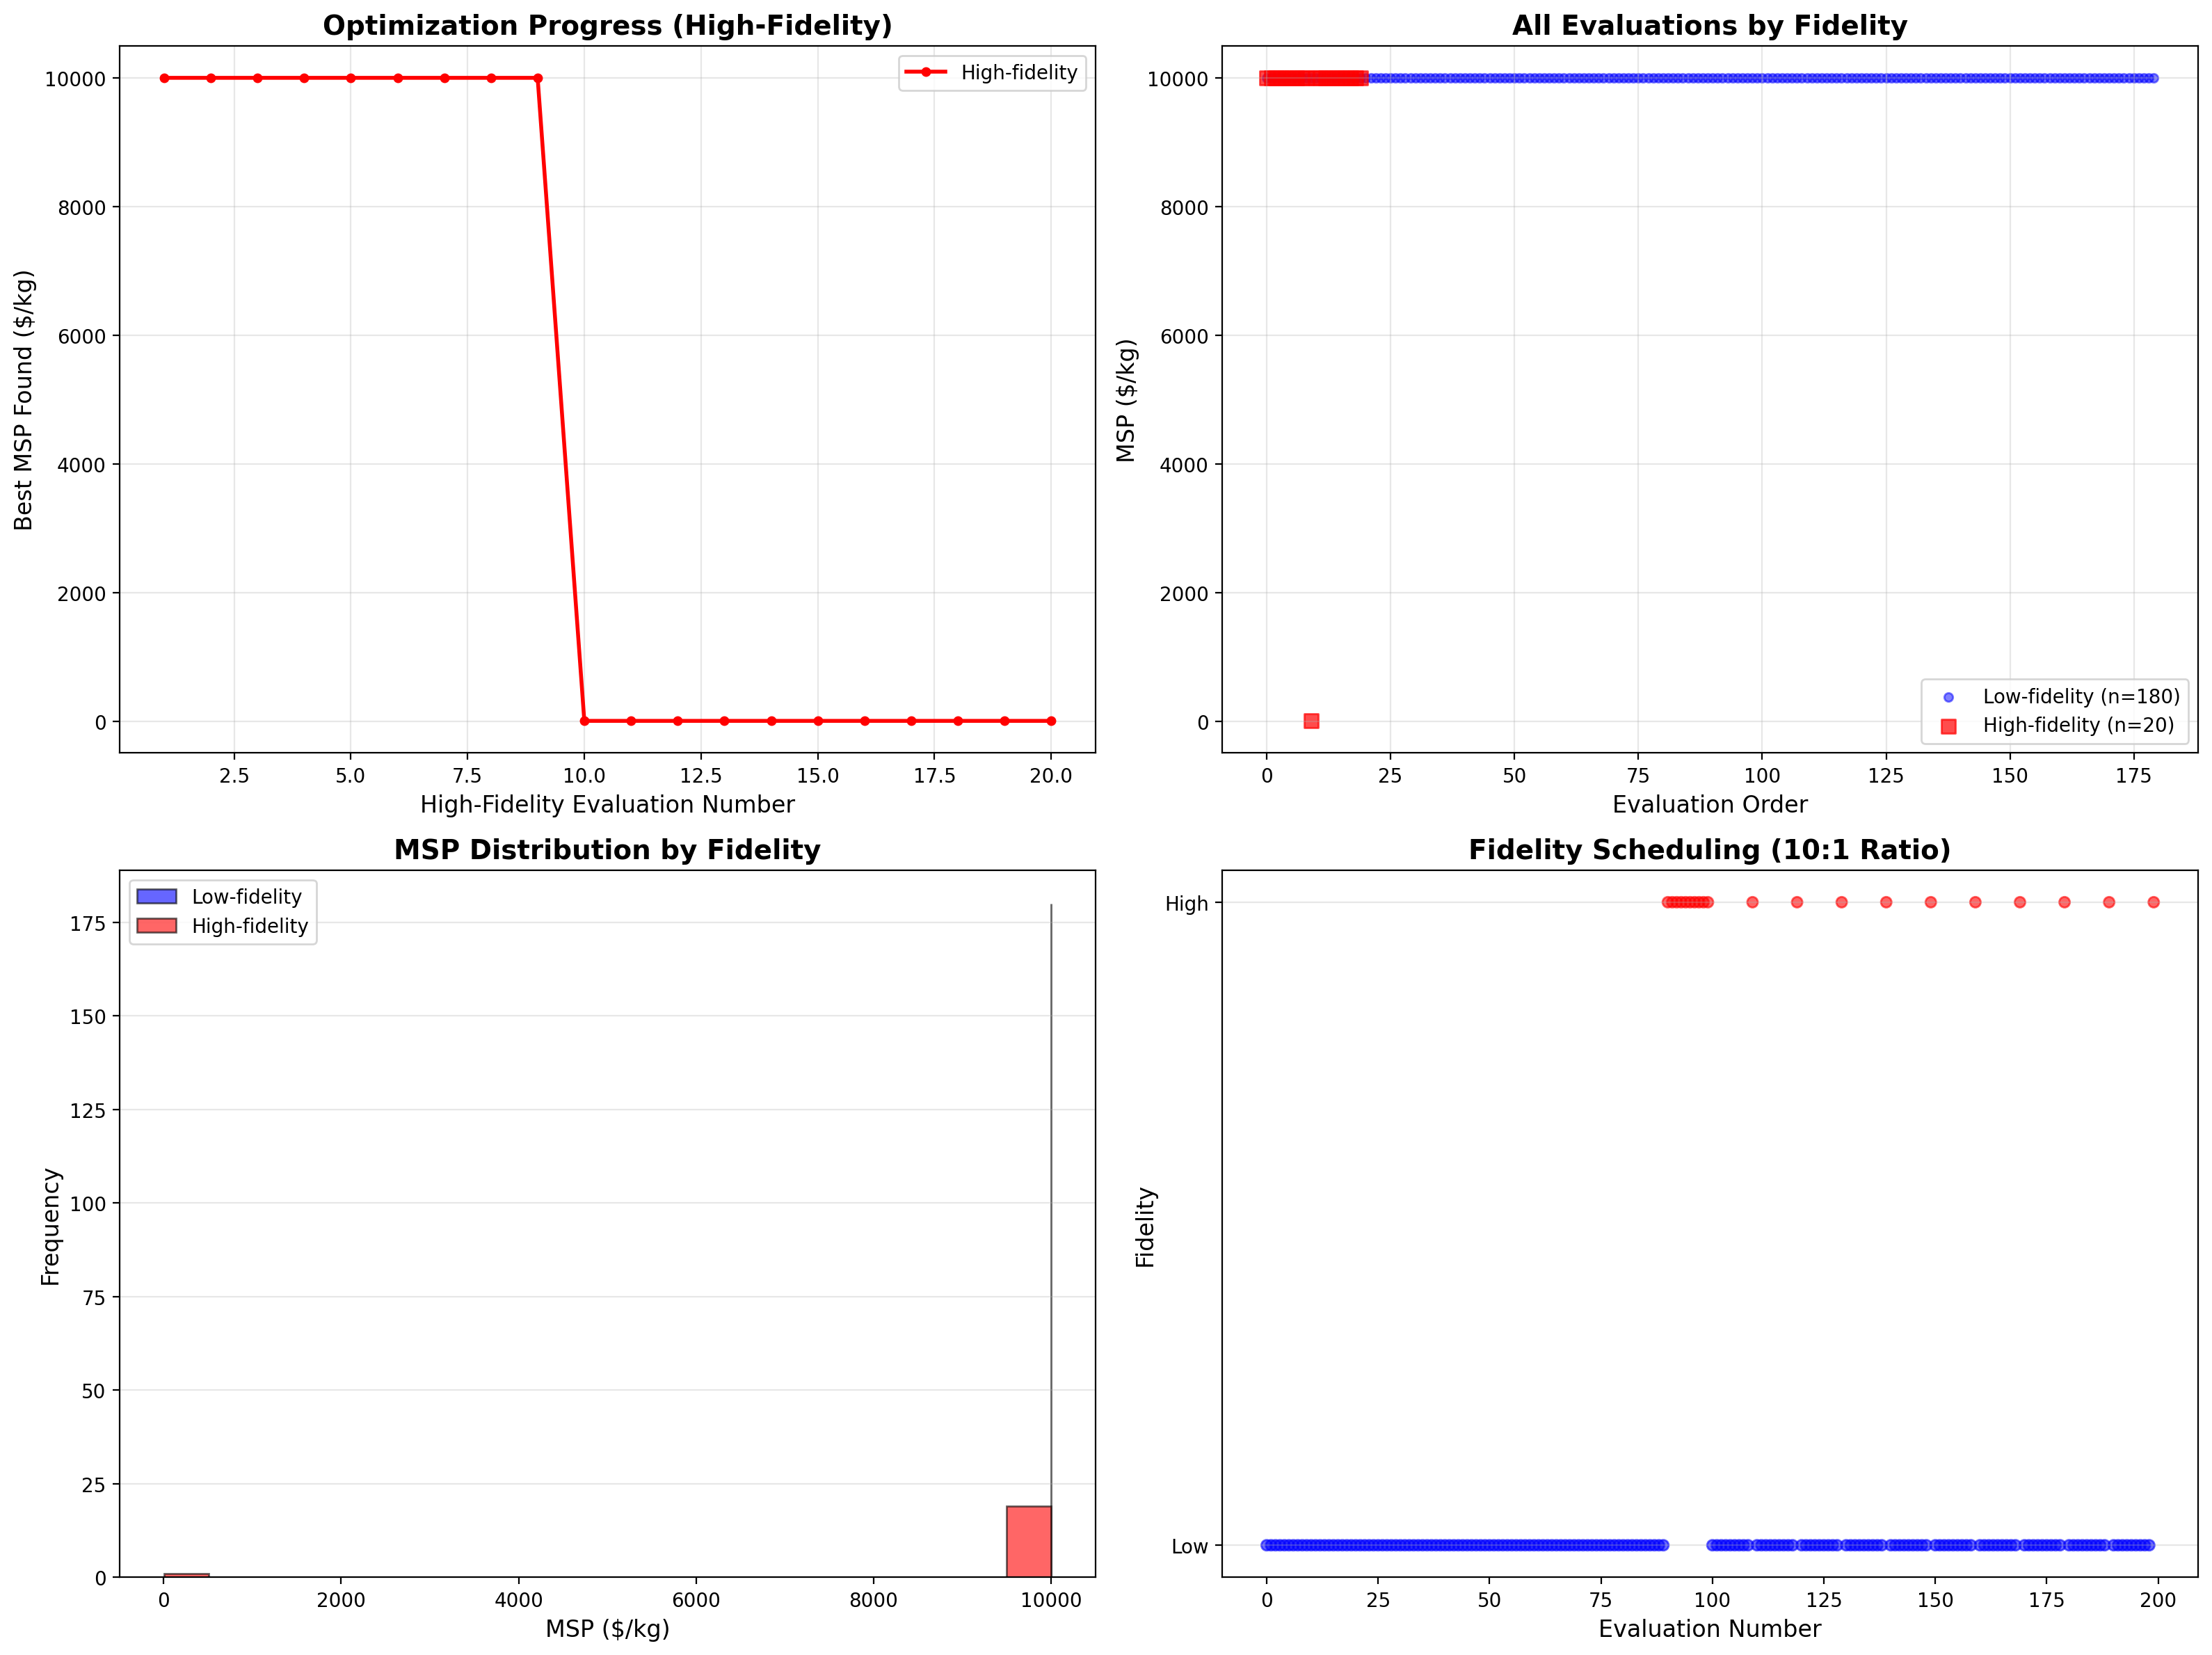


SUMMARY STATISTICS

Low-Fidelity (n=180):
  Best MSP: 10000.0000
  Mean MSP: 10000.0000
  Std MSP: 0.0000

High-Fidelity (n=20):
  Best MSP: 6.0675
  Mean MSP: 9500.3034
  Std MSP: 2234.7112

Overall:
  Best MSP: 6.0675
  Total evaluations: 200
  Fidelity ratio: 180/20 = 9.00:1


In [20]:
# Load results
df_results = pd.read_csv(results_file)

# Separate by fidelity
df_low = df_results[df_results['fidelity'] == 'low']
df_high = df_results[df_results['fidelity'] == 'high']

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Best-so-far curve (high-fidelity)
ax = axes[0, 0]
high_msp = df_high['MSP'].values
high_best = np.minimum.accumulate(high_msp)
ax.plot(range(1, len(high_best) + 1), high_best, 'ro-', linewidth=2, markersize=4, label='High-fidelity')
ax.set_xlabel('High-Fidelity Evaluation Number', fontsize=12)
ax.set_ylabel('Best MSP Found ($/kg)', fontsize=12)
ax.set_title('Optimization Progress (High-Fidelity)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# 2. All evaluations
ax = axes[0, 1]
low_indices = np.arange(len(df_low))
high_indices = np.arange(len(df_high))
ax.scatter(low_indices, df_low['MSP'].values, c='blue', alpha=0.5, s=20, label=f'Low-fidelity (n={len(df_low)})')
ax.scatter(high_indices, df_high['MSP'].values, c='red', alpha=0.7, s=50, marker='s', label=f'High-fidelity (n={len(df_high)})')
ax.set_xlabel('Evaluation Order', fontsize=12)
ax.set_ylabel('MSP ($/kg)', fontsize=12)
ax.set_title('All Evaluations by Fidelity', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Distribution comparison
ax = axes[1, 0]
ax.hist(df_low['MSP'].dropna(), bins=30, alpha=0.6, color='blue', label='Low-fidelity', edgecolor='black')
ax.hist(df_high['MSP'].dropna(), bins=20, alpha=0.6, color='red', label='High-fidelity', edgecolor='black')
ax.set_xlabel('MSP ($/kg)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('MSP Distribution by Fidelity', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Fidelity schedule
ax = axes[1, 1]
fidelity_binary = [1 if f == 'high' else 0 for f in df_results['fidelity']]
ax.scatter(range(len(fidelity_binary)), fidelity_binary, c=['red' if f == 1 else 'blue' for f in fidelity_binary], alpha=0.6, s=30)
ax.set_xlabel('Evaluation Number', fontsize=12)
ax.set_ylabel('Fidelity', fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'])
ax.set_title('Fidelity Scheduling (10:1 Ratio)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{results_dir}/dngo_bo_visualization_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"\nLow-Fidelity (n={len(df_low)}):")
print(f"  Best MSP: {df_low['MSP'].min():.4f}")
print(f"  Mean MSP: {df_low['MSP'].mean():.4f}")
print(f"  Std MSP: {df_low['MSP'].std():.4f}")

print(f"\nHigh-Fidelity (n={len(df_high)}):")
print(f"  Best MSP: {df_high['MSP'].min():.4f}")
print(f"  Mean MSP: {df_high['MSP'].mean():.4f}")
print(f"  Std MSP: {df_high['MSP'].std():.4f}")

print(f"\nOverall:")
print(f"  Best MSP: {df_results['MSP'].min():.4f}")
print(f"  Total evaluations: {len(df_results)}")
print(f"  Fidelity ratio: {len(df_low)}/{len(df_high)} = {len(df_low)/len(df_high):.2f}:1")